In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from config import BENCHMARKS
from utils import plot_pool_distribution
from sensitivity_analysis.sensitivity_utils import (
    load_scores,
    sweep_thresholds,
    plot_sweep,
    print_sparsity_check,
)

BENCHMARK = "WORKERS"
BENCH_PARAMS = BENCHMARKS[BENCHMARK]
METRIC_COL = BENCH_PARAMS["metric_col"]
THRESHOLD = BENCH_PARAMS["threshold"]
METRIC_OP = BENCH_PARAMS["metric_op"]
SAMPLE_SIZE = BENCH_PARAMS["sample_size"]
SPARSITY_MIN = BENCH_PARAMS["sparsity_min"]
XLABEL = "Work-Hours Ratio (WHR)"

SOURCES = [("ips_full", "IPs")]
SWEEP_RANGE = np.arange(0.25, 0.71, 0.05)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

GRAPH_DIR = Path('sensitivity_analysis/figures')
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print(f"Benchmark: {BENCHMARK}")
print(f"Threshold: {METRIC_COL} {METRIC_OP} {THRESHOLD}")
print(f"Sparsity filter: ratio_active >= {SPARSITY_MIN}")
print(f"Sample size: {SAMPLE_SIZE}")

Benchmark: WORKERS
Threshold: whr >= 0.6
Sparsity filter: ratio_active >= 0.23
Sample size: 25


## Hourly

In [2]:
print("Loading hourly scores:")
scores_hourly_raw = load_scores("hourly", BENCHMARK, SOURCES)

scores_hourly = {}
for label, df in scores_hourly_raw.items():
    filtered = df[df["ratio_active"] >= SPARSITY_MIN].copy()
    print(f"  {label}: {len(filtered)}/{len(df)} pass sparsity >= {SPARSITY_MIN}")
    scores_hourly[label] = filtered

Loading hourly scores:
  IPs: 275124 series
  IPs: 60022/275124 pass sparsity >= 0.23


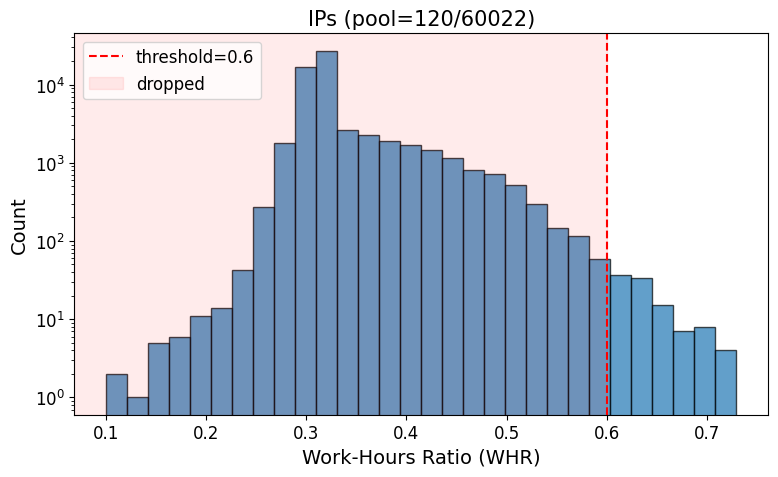

In [3]:
plot_pool_distribution(
    [(scores_hourly[label], label) for _, label in SOURCES],
    metric_col=METRIC_COL,
    threshold=THRESHOLD,
    metric_op=METRIC_OP,
    xlabel=XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / f"{BENCHMARK}_pool_distribution_hourly.pdf",
)

In [4]:
sweep_hourly = sweep_thresholds(scores_hourly, METRIC_COL, SWEEP_RANGE, metric_op=METRIC_OP)
display(sweep_hourly)

,threshold,IPs pool,IPs median
0,0.25,59932,0.312
1,0.30,54958,0.313
2,0.35,11387,0.410
3,0.40,6518,0.447
4,0.45,3062,0.490
5,0.50,1202,0.527
6,0.55,354,0.579
7,0.60,120,0.629
8,0.65,29,0.674
9,0.70,7,0.709


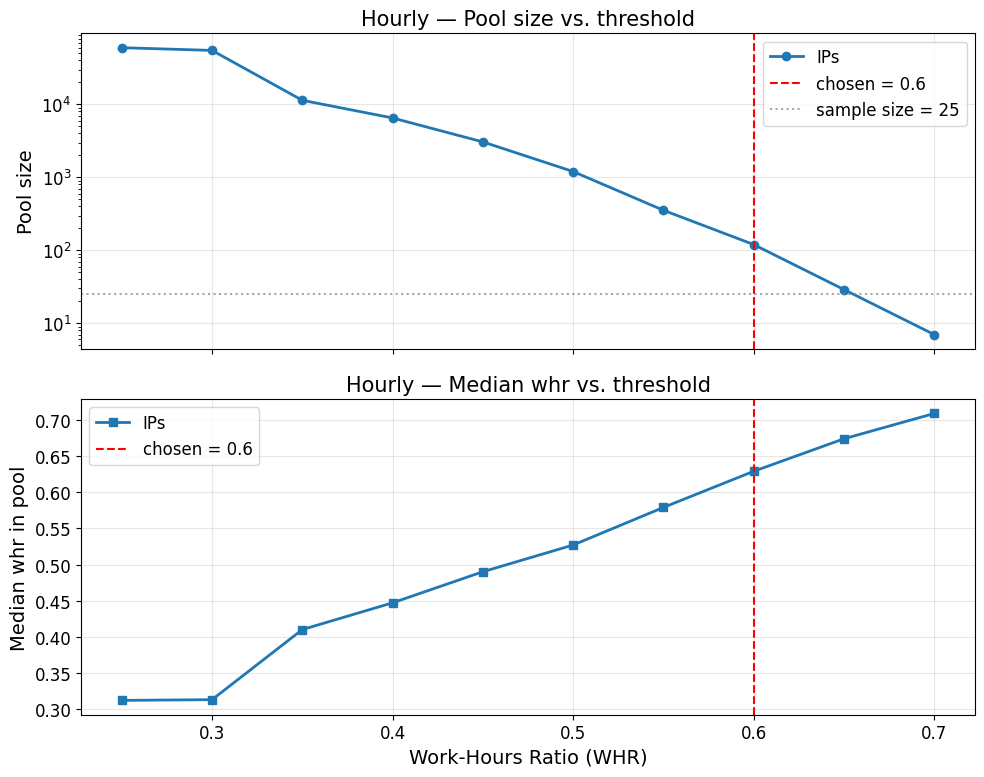

In [5]:
plot_sweep(sweep_hourly, "Hourly", THRESHOLD, SAMPLE_SIZE, XLABEL, METRIC_COL,
           save_path=GRAPH_DIR / f"{BENCHMARK}_sweep_hourly.pdf", log_y=True)

### Non-binding Sparsity Check

The hourly `ips_full` scores were computed with a lower sparsity cutoff, so WHR is available for series below the current 23% threshold. This lets us directly count how many would qualify on WHR alone but get removed by sparsity.

In [6]:
print_sparsity_check(scores_hourly_raw["IPs"], METRIC_COL, THRESHOLD, SPARSITY_MIN)

Total series:                          275,124
whr >= 0.6 alone:                        24,113
whr >= 0.6 AND sparsity >= 0.23:            120
Removed by sparsity (on top of whr):    23,993  (99.5% of pool)

Sparsity is the dominant filter: it shrinks the whr-only pool
from 24,113 down to 120 (99.5% removed).


## 10-Minute

In [7]:
print("Loading 10-minute scores:")
scores_10min_raw = load_scores("10min", BENCHMARK, SOURCES)

scores_10min = {}
for label, df in scores_10min_raw.items():
    filtered = df[df["ratio_active"] >= SPARSITY_MIN].copy()
    print(f"  {label}: {len(filtered)}/{len(df)} pass sparsity >= {SPARSITY_MIN}")
    scores_10min[label] = filtered

Loading 10-minute scores:
  IPs: 275124 series
  IPs: 49513/275124 pass sparsity >= 0.23


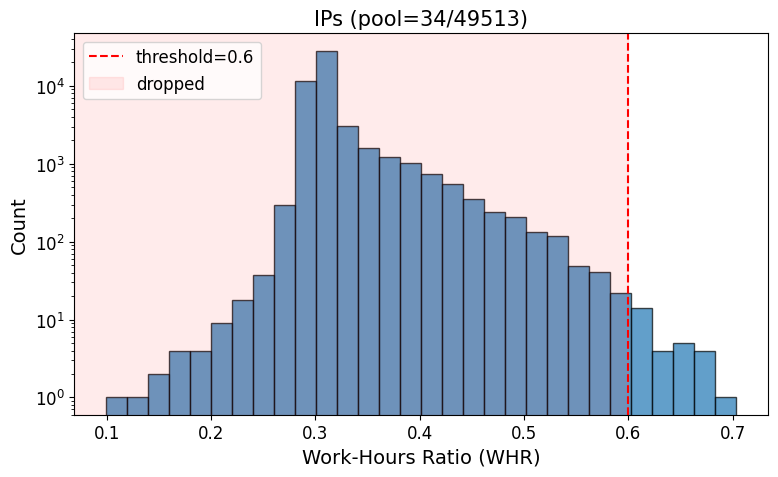

In [8]:
plot_pool_distribution(
    [(scores_10min[label], label) for _, label in SOURCES],
    metric_col=METRIC_COL,
    threshold=THRESHOLD,
    metric_op=METRIC_OP,
    xlabel=XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / f"{BENCHMARK}_pool_distribution_10min.pdf",
)

In [9]:
sweep_10min = sweep_thresholds(scores_10min, METRIC_COL, SWEEP_RANGE, metric_op=METRIC_OP)
display(sweep_10min)

,threshold,IPs pool,IPs median
0,0.25,49461,0.308
1,0.30,38740,0.311
2,0.35,5594,0.395
3,0.40,2555,0.438
4,0.45,1016,0.488
5,0.50,408,0.531
6,0.55,119,0.574
7,0.60,34,0.618
8,0.65,7,0.673
9,0.70,1,0.704


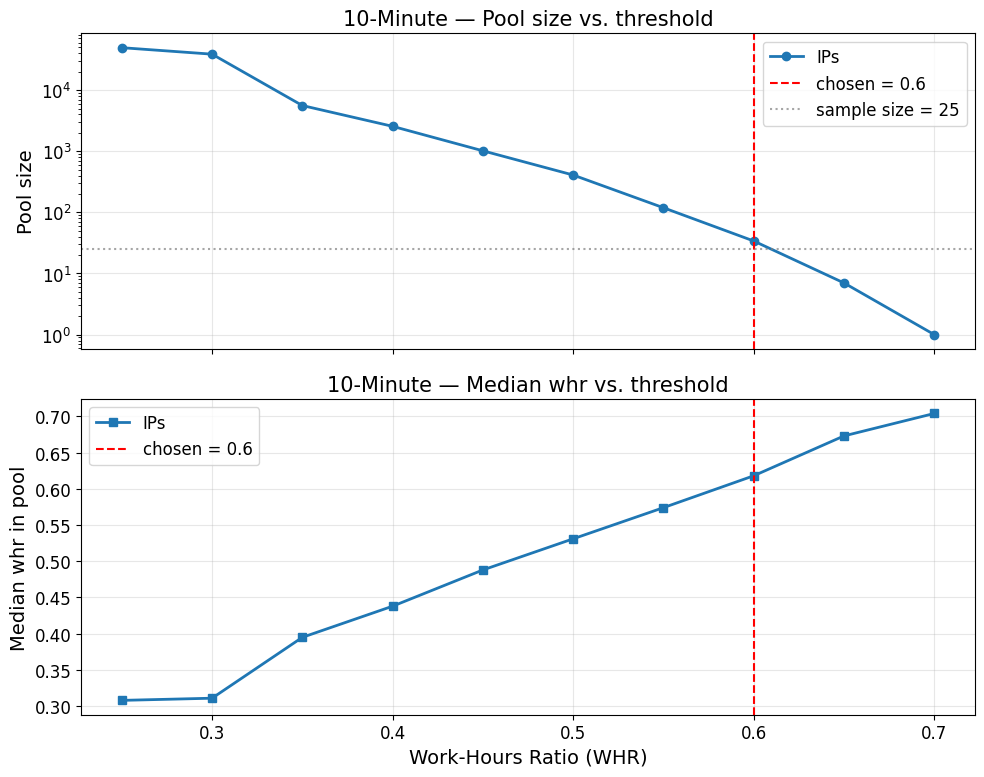

In [10]:
plot_sweep(sweep_10min, "10-Minute", THRESHOLD, SAMPLE_SIZE, XLABEL, METRIC_COL,
           save_path=GRAPH_DIR / f"{BENCHMARK}_sweep_10min.pdf", log_y=True)

### Non-binding Sparsity Check

The 10-minute scores were computed at the exact 23% sparsity cutoff, so sub-sparsity WHR is not available. We check the minimum `ratio_active` among WHR-qualifying series instead.

In [11]:
print_sparsity_check(scores_10min_raw["IPs"], METRIC_COL, THRESHOLD, SPARSITY_MIN)

Total series:                          275,124
whr >= 0.6 alone:                        20,479
whr >= 0.6 AND sparsity >= 0.23:             34
Removed by sparsity (on top of whr):    20,445  (99.8% of pool)

Sparsity is the dominant filter: it shrinks the whr-only pool
from 20,479 down to 34 (99.8% removed).
